In [1]:
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\Vivek\Downloads\BankWages.csv")

# Overview

In [4]:
df.head()

,rownames,job,education,gender,minority
0,1,manage,15,male,no
1,2,admin,16,male,no
2,3,admin,12,female,no
3,4,admin,8,female,no
4,5,admin,15,male,no


In [5]:
df.describe(include = "all")

,rownames,job,education,gender,minority
count,474.000000,474,474.000000,474,474
unique,NaN,3,NaN,2,2
top,NaN,admin,NaN,male,no
freq,NaN,363,NaN,258,370
mean,237.500000,NaN,13.491561,NaN,NaN
std,136.976275,NaN,2.884846,NaN,NaN
min,1.000000,NaN,8.000000,NaN,NaN
25%,119.250000,NaN,12.000000,NaN,NaN
50%,237.500000,NaN,12.000000,NaN,NaN
75%,355.750000,NaN,15.000000,NaN,NaN


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 474 entries, 0 to 473
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   rownames   474 non-null    int64
 1   job        474 non-null    str  
 2   education  474 non-null    int64
 3   gender     474 non-null    str  
 4   minority   474 non-null    str  
dtypes: int64(2), str(3)
memory usage: 18.6 KB


## Insights
##### admins are more
##### minors are less
##### nearly equal male female ratio

# Distribution of each categorical variable

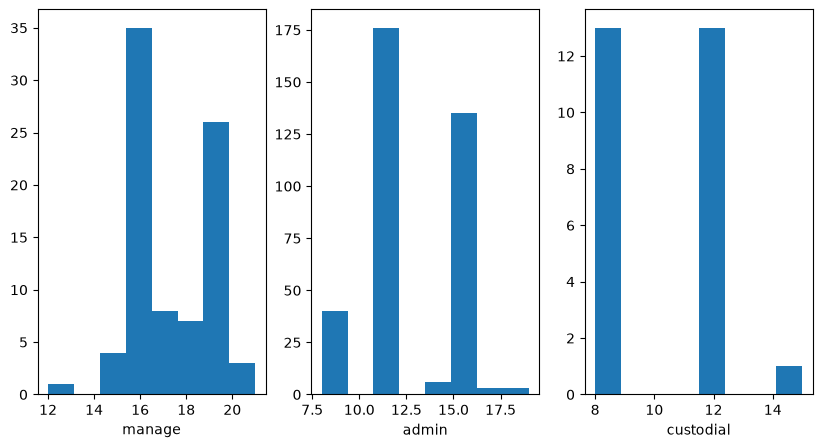

In [31]:
job_cat = df['job'].unique().tolist()
fig,ax = plt.subplots(1,3,figsize=(10,5))
for i in range(3):
    ax[i].hist(df[df['job']==job_cat[i]]['education'], bins = 8)
    ax[i].set_xlabel(job_cat[i])


# Complete analysis in single chart

In [7]:
df_grouped = df.groupby(['job', 'education', 'gender','minority'])['minority'].count()

In [8]:
df_grouped = pd.DataFrame(df_grouped)

In [9]:
df_grouped

minority
job       education gender minority          
admin     8         female no              27
                           yes              3
                    male   no               6
                           yes              4
          12        female no             101
                           yes             27
                    male   no              30
                           yes             18
          14        male   no               5
                           yes              1
          15        female no              25
                           yes              8
                    male   no              61
                           yes             17
          16        female no              12
                           yes              2
                    male   no               6
                           yes              4
          17        female no               1
                    male   yes              2
          18        male   no               1
                           yes              1
          19        male   no               1
custodial 8         male   no               6
                           yes              7
          12        male   no               8
                           yes              5
          15        male   yes              1
manage    12        male   yes              1
          15        male   no               4
          16        female no              10
                    male   no              24
                           yes              1
          17        male   no               7
                           yes              1
          18        male   no               7
          19        male   no              25
                           yes              1
          20        male   no               2
          21        male   no               1

<Axes: >

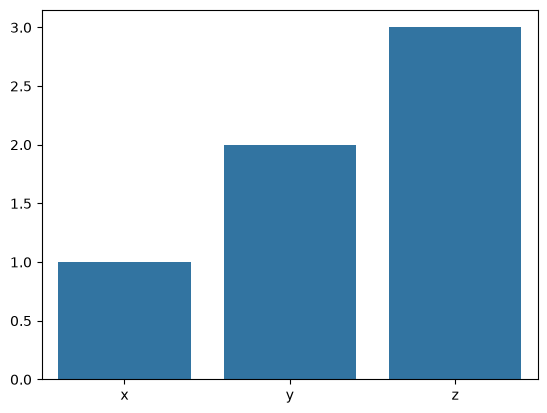

In [10]:
sns.barplot(x = ['x','y','z'], y = [1,2,3])

In [11]:
df_grouped2 = pd.DataFrame(df.groupby('job')['job'].count())
df_grouped2.rename({'job':'count'},inplace=True)

In [12]:
df_grouped2

,job
job,
admin,363
custodial,27
manage,84


In [13]:
df_grouped2.index.array

<StringArray>
['admin', 'custodial', 'manage']
Length: 3, dtype: str

In [14]:
df_grouped2.values

array([[363],
       [ 27],
       [ 84]])

In [15]:
df_grouped2 = pd.DataFrame(columns = ['count'], data=df_grouped2.values, index=df_grouped2.index.array)

In [16]:
df_grouped2

,count
admin,363
custodial,27
manage,84


In [17]:
df_grouped2.index

Index(['admin', 'custodial', 'manage'], dtype='str')

In [18]:
df_grouped2['count'].values

array([363,  27,  84])

<Axes: xlabel='None'>

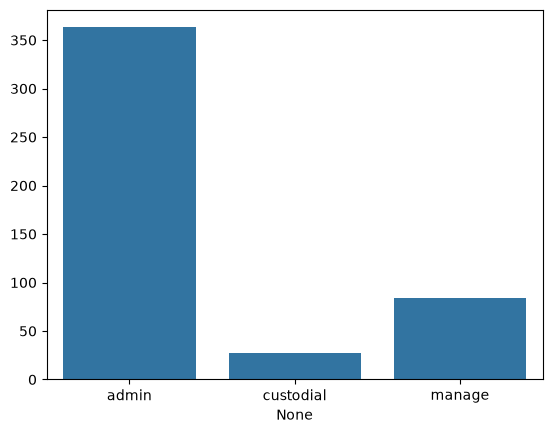

In [19]:
sns.barplot(x=df_grouped2.index,y=df_grouped2['count'].values)

In [20]:
df.columns

Index(['rownames', 'job', 'education', 'gender', 'minority'], dtype='str')

In [84]:
df_grouped

count
job       education gender minority       
admin     8         female no           27
                           yes           3
                    male   no            6
                           yes           4
          12        female no          101
                           yes          27
                    male   no           30
                           yes          18
          14        male   no            5
                           yes           1
          15        female no           25
                           yes           8
                    male   no           61
                           yes          17
          16        female no           12
                           yes           2
                    male   no            6
                           yes           4
          17        female no            1
                    male   yes           2
          18        male   no            1
                           yes           1
          19        male   no            1
custodial 8         male   no            6
                           yes           7
          12        male   no            8
                           yes           5
          15        male   yes           1
manage    12        male   yes           1
          15        male   no            4
          16        female no           10
                    male   no           24
                           yes           1
          17        male   no            7
                           yes           1
          18        male   no            7
          19        male   no           25
                           yes           1
          20        male   no            2
          21        male   no            1

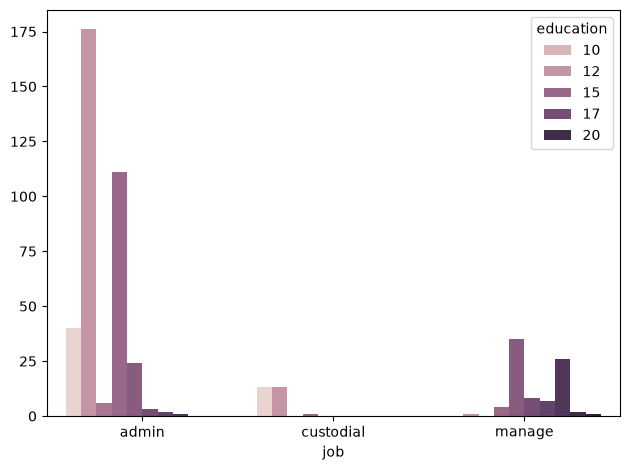

In [ ]:
#sns.barplot(x=df['job'],y=df['job'].count() ,hue=df['gender'])
bars = sns.barplot(x=df_grouped.index.get_level_values(0),y=df_grouped['count'].values,
            estimator='sum',
            hue=df_grouped.index.get_level_values(1),
            errorbar=None,
            width = 0.8)

#plt.tight_layout()

In [81]:
df_grouped.index.get_level_values(0)

Index(['admin', 'admin', 'admin', 'admin', 'admin', 'admin', 'admin', 'admin',
       'admin', 'admin', 'admin', 'admin', 'admin', 'admin', 'admin', 'admin',
       'admin', 'admin', 'admin', 'admin', 'admin', 'admin', 'admin',
       'custodial', 'custodial', 'custodial', 'custodial', 'custodial',
       'manage', 'manage', 'manage', 'manage', 'manage', 'manage', 'manage',
       'manage', 'manage', 'manage', 'manage', 'manage'],
      dtype='str', name='job')

In [64]:
df_grouped.values.shape

(40, 1)

In [72]:
df_grouped.rename(columns = {'minority':'count'},inplace=True)

In [79]:
df_grouped['count'].values

array([ 27,   3,   6,   4, 101,  27,  30,  18,   5,   1,  25,   8,  61,
        17,  12,   2,   6,   4,   1,   2,   1,   1,   1,   6,   7,   8,
         5,   1,   1,   4,  10,  24,   1,   7,   1,   7,  25,   1,   2,
         1])